In [9]:
library(Seurat)
library(nicheDE)
library(qs)
library(glue)
library(glue)
library(ggplot2)
library(patchwork)
library(latex2exp)
library(scCustomize)
library(scico)
library(ComplexHeatmap)
library(ggtree)
library(ggsci)
library(latex2exp)
library(ggrepel)
library(org.Hs.eg.db)
library(clusterProfiler)
library(RColorBrewer)
library(Polychrome)
library(stringr) 
library(readxl)
library(parallel)
library(ggpubr)
library(dplyr)
library(tidyr)

Warning message:
“package ‘ggtree’ was built under R version 4.4.2”
ggtree v3.14.0 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

Guangchuang Yu.  Data Integration, Manipulation and Visualization of
Phylogenetic Trees (1st edition). Chapman and Hall/CRC. 2022,
doi:10.1201/9781003279242, ISBN: 9781032233574


Attaching package: ‘ggtree’


The following object is masked from ‘package:tidyr’:

    expand


The following object is masked from ‘package:ggpubr’:

    rotate


The following object is masked from ‘package:IRanges’:

    collapse


The following object is masked from ‘package:S4Vectors’:

    expand




# 3B

In [2]:
lognorm_data <- readRDS("/data1/deyk/harry/RA_Xenium/data/Zhang_Nat_2023_AMP/qc_mRNA_314011cells_log_normalized_matrix.rds")
metadata_all <- readRDS("/data1/deyk/harry/RA_Xenium/data/Zhang_Nat_2023_AMP/all_cells_reference.rds")
rownames(metadata_all$meta_data) <- metadata_all$meta_data$cell
amp_atlas <- CreateSeuratObject(counts=lognorm_data, meta.data=metadata_all$meta_data, assay="RNA")
amp_atlas <- SetAssayData(object = amp_atlas, layer = 'data', new.data = lognorm_data)

In [3]:
DC <- c("M-9:", "M-10:", "M-11:", "M-12:", "M-13:", "M-14:")
Monocytes <- c("M-6:", "M-7:","M-8:")
SPP1hi <- c("M-3:", "M-4:")
Tissue <- c("M-0:", "M-1:", "M-2:", "M-5: ")
cluster_list <- list(DC=DC,
                     Monocytes=Monocytes,
                     SPP1hi=SPP1hi,
                     Tissue=Tissue)
lapply(cluster_list, function(clusters){
    pattern <- paste(clusters, collapse="|")
    amp_clusters <- unique(amp_atlas@meta.data$cluster_name)
    amp_clusters[str_detect(amp_clusters, regex(pattern))]
}) -> cluster_list
Idents(amp_atlas) <- "cluster_name"
amp_atlas_subset <- subset(amp_atlas, idents=unname(unlist(cluster_list)))
unlist(lapply(names(cluster_list), function(cluster){
    tmp <- rep(cluster, length(cluster_list[[cluster]]))
    names(tmp) <- cluster_list[[cluster]]
    tmp
})) -> rename_cluster
amp_atlas_subset@meta.data$cluster_macs <- rename_cluster[amp_atlas_subset@meta.data$cluster_name]
Idents(amp_atlas_subset) <- "cluster_macs"

In [4]:
samac_genes <- read_xlsx("/data1/deyk/harry/RA_Xenium/data/Ian_gene_list_xenium_experiments/SAMac_fibrolysis.xlsx")

In [5]:
genes <- samac_genes$`Top 20 SAMac genes`
avg_exp <- AverageExpression(object=amp_atlas_subset, group.by="cluster_macs", slot="data", features=genes)
percent_expressing <- Percent_Expressing(seurat_object=amp_atlas_subset, features=genes, group_by="cluster_macs")
percent_expressing %>%
    mutate(gene=rownames(.)) %>%
    pivot_longer(!gene, names_to="cell_type", values_to="pct_exp") -> percent_expressing
scaled_avg_exp <- t(scale(t(avg_exp$RNA)))
scaled_avg_exp <- MinMax(scaled_avg_exp, max=2.5, min=-2.5)
data.frame(scaled_avg_exp) %>%
    mutate(gene=rownames(.)) %>%
    pivot_longer(!gene, names_to="cell_type", values_to="z_avg_exp") -> scaled_avg_exp
percent_expressing %>%
    left_join(scaled_avg_exp, by=c("gene", "cell_type")) -> macs_markers_plot
color_scale_breaks <- round(unname(c(quantile(macs_markers_plot$z_avg_exp, 0.1), 0, quantile(macs_markers_plot$z_avg_exp, 0.9))))

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


In [6]:
ggplot(macs_markers_plot, aes(gene,
                              cell_type,
                              color=z_avg_exp,
                              size=pct_exp)) +
    scale_size_continuous(range=c(0, 4), breaks=seq(25, 75, 25)) +
    scale_color_scico(palette="vik", midpoint=0, breaks=color_scale_breaks) +
    geom_point() +
    theme_bw() +
    theme(axis.text.x=element_text(colour="black", angle=45, hjust=1, size=8),
          axis.text.y=element_text(colour="black", size=8),
          legend.key.height=unit(0.4, 'cm'),
          legend.key.width=unit(0.35, 'cm'),
          panel.grid.major=element_blank(),
          panel.grid.minor=element_blank(),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7)) +
    ylab("") +
    xlab("") +
    scale_y_discrete(labels=c(Tissue="Tissue",
                              SPP1hi=expression(SPP1^{hi}),
                              Monocytes="Monocytes",
                              DC="DC")) +
    labs(color="Scaled\nExpression",
         size="% Expressed") -> macs_markers_plot_image

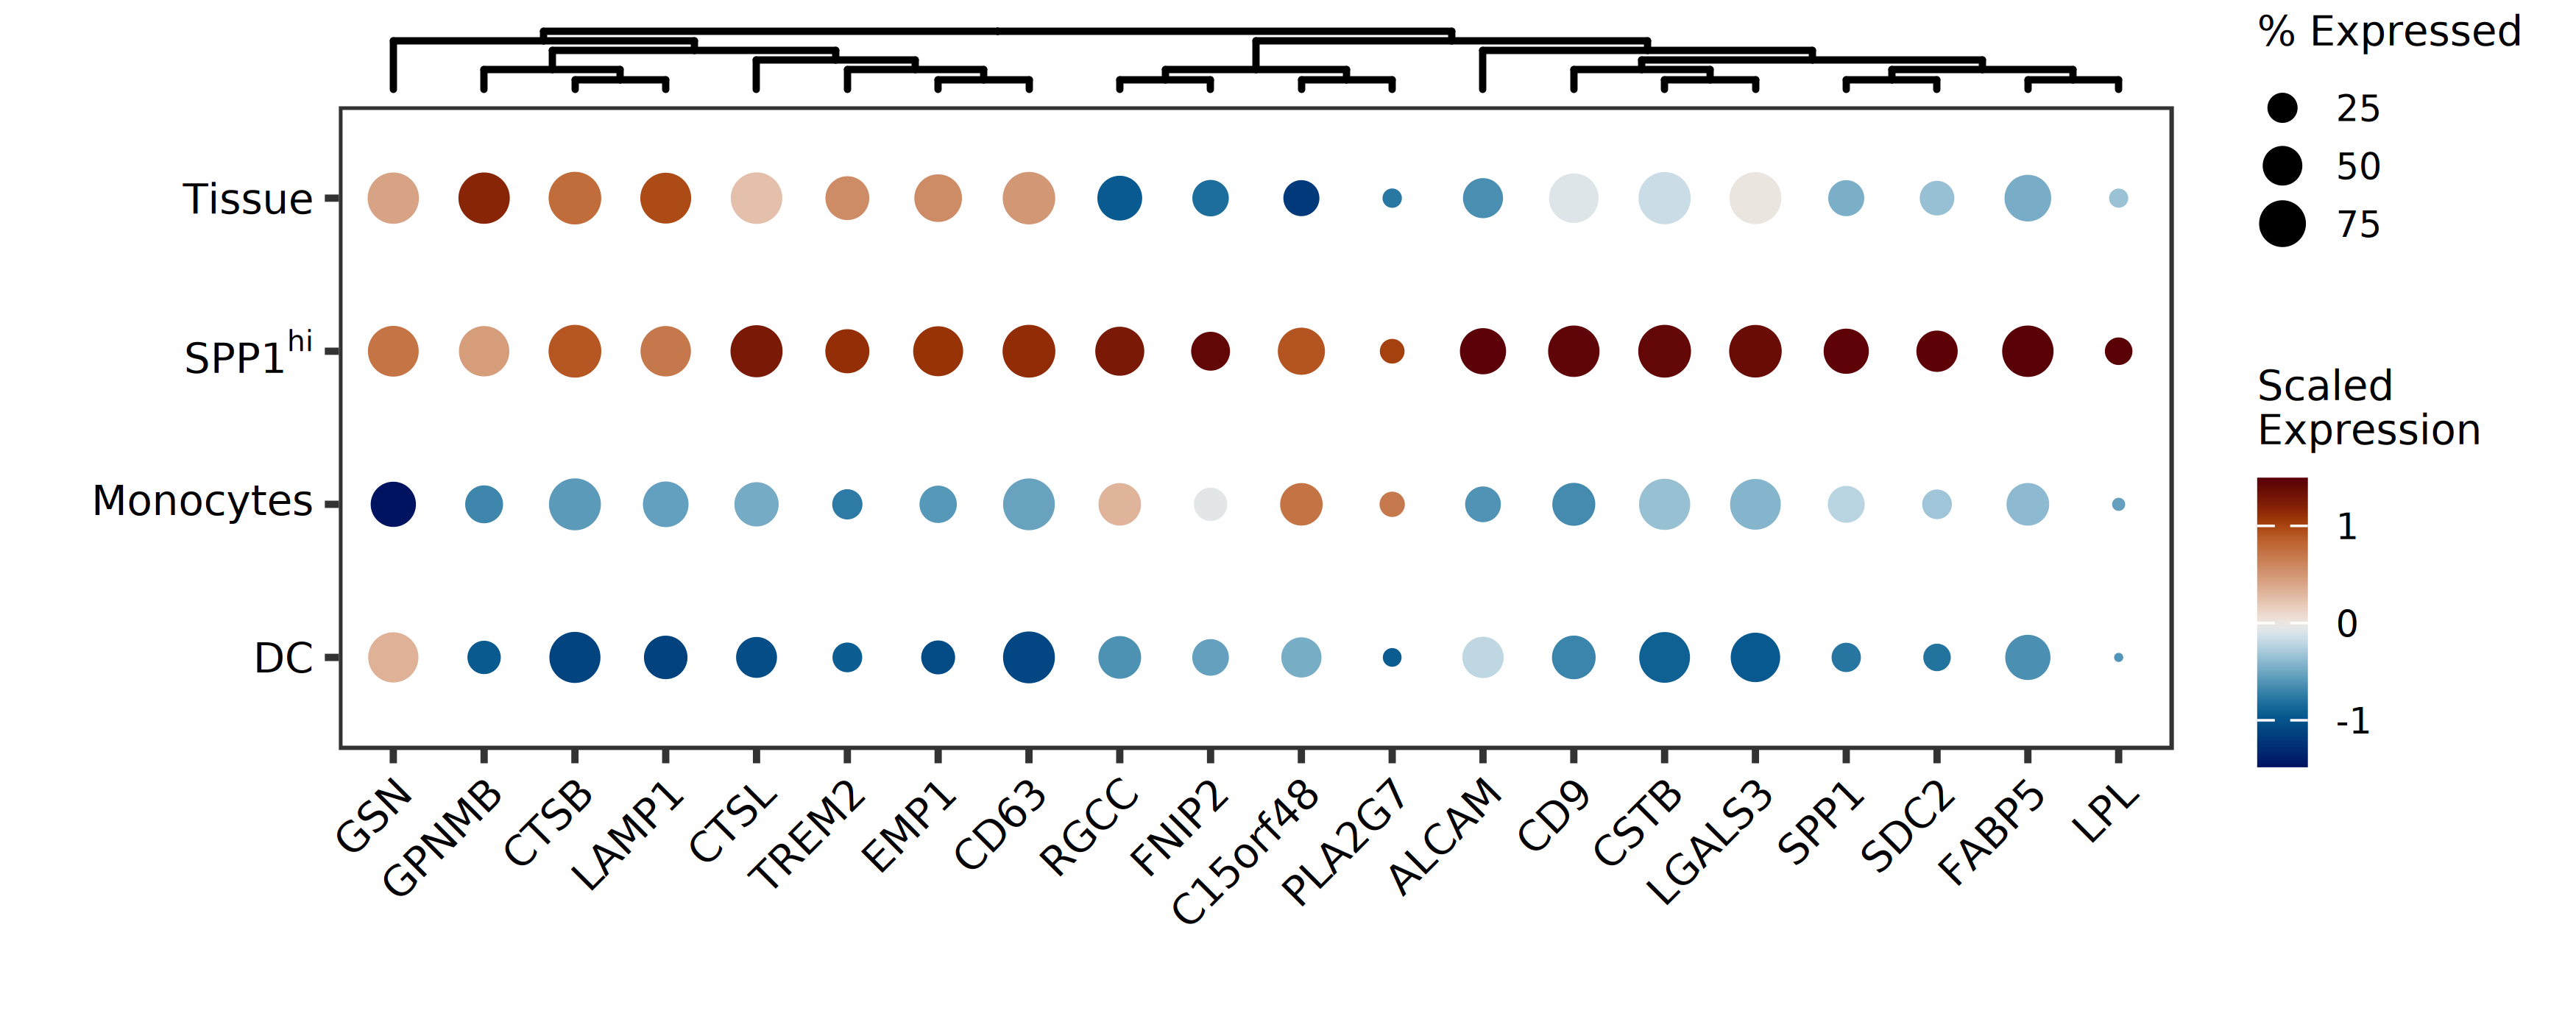

In [10]:
options(repr.plot.width = 7, repr.plot.height = 2.8, repr.plot.res = 500)
macs_markers_plot %>%
    select(-pct_exp) %>%
    pivot_wider(names_from=cell_type, values_from=z_avg_exp) %>%
    tibble::column_to_rownames("gene") %>%
    as.matrix(.) -> dend_data
dend_data  %>%
    dist() %>%
    hclust() %>%
    ggtree(branch.length="none") +
    layout_dendrogram() -> gene_dendro
macs_markers_plot_image %>%
    aplot::insert_top(gene_dendro, height=0.1) -> macs_markers_plot_image_clustered
macs_markers_plot_image_clustered

# 3C

In [25]:
excel_path <- "/data1/deyk/harry/RA_Xenium/data/Ian_Experiment_DEGs_04302025/Comparisons_for_Harry_042925.xlsx"
all_degs_df <- lapply(excel_sheets(excel_path)[-1], read_excel, path=excel_path, skip=1)
names(all_degs_df) <- excel_sheets(excel_path)[-1]
lapply(all_degs_df, function(res){
    res <- res[, 1:3]
    colnames(res) <- c("Gene", "Log2FC", "Abs_Log2FC")
    res %>%
        filter(Gene %in% rownames(amp_atlas_subset))
}) -> all_degs_df

New names:
• `gene_name` -> `gene_name...1`
• `m-18h_v_None.Log2FC` -> `m-18h_v_None.Log2FC...2`
• `Abs_Log2FC` -> `Abs_Log2FC...3`
• `` -> `...4`
• `gene_name` -> `gene_name...5`
• `m-18h_v_None.Log2FC` -> `m-18h_v_None.Log2FC...6`
• `Abs_Log2FC` -> `Abs_Log2FC...7`
• `` -> `...8`
• `gene_name` -> `gene_name...9`
• `m-18h_v_None.Log2FC` -> `m-18h_v_None.Log2FC...10`
• `Abs_Log2FC` -> `Abs_Log2FC...11`
• `` -> `...12`
• `gene_name` -> `gene_name...13`
• `m-18h_v_None.Log2FC` -> `m-18h_v_None.Log2FC...14`
• `Abs_Log2FC` -> `Abs_Log2FC...15`
New names:
• `gene_name` -> `gene_name...1`
• `m-72h_v_None` -> `m-72h_v_None...2`
• `Abs_Log2FC` -> `Abs_Log2FC...3`
• `` -> `...4`
• `gene_name` -> `gene_name...5`
• `m-72h_v_None` -> `m-72h_v_None...6`
• `Abs_Log2FC` -> `Abs_Log2FC...7`
• `` -> `...8`
• `gene_name` -> `gene_name...9`
• `m-72h_v_None` -> `m-72h_v_None...10`
• `Abs_Log2FC` -> `Abs_Log2FC...11`
• `` -> `...12`
• `gene_name` -> `gene_name...13`
• `m-72h_v_None` -> `m-72h_v_None...14`


In [26]:
all_degs_df <- all_degs_df[c("m6t-72_v_m-72", "mtp-72_v_m-72")]

In [27]:
all_degs_df <- lapply(all_degs_df, function(df){
  
  df_abs  <- df %>% arrange(desc(Abs_Log2FC))
  df_up   <- df %>% arrange(desc(Log2FC))
  df_down <- df %>% arrange(Log2FC)
  list(
    all_sig      = df %>% filter( Abs_Log2FC > 1 )
  )
})

In [28]:
all_degs_df <- lapply(all_degs_df, function(dfs){
    lapply(names(dfs), function(name){
        if(grepl("all", name)){
            df <- dfs[[name]]
            setNames(df$Log2FC, df$Gene)
        }else{
            df <- dfs[[name]]
            setNames(df$Abs_Log2FC, df$Gene)
        }
    }) -> lists.tmp
    names(lists.tmp) <- names(dfs)
    lists.tmp
})

In [30]:
getWeightedModuleScore <- function(features,
                                   feature_weights,
                                   seurat_obj,
                                   module_name){
    assay.data <- GetAssayData(seurat_obj, assay="RNA", layer="data")
    data.avg <- rowMeans(assay.data)
    data.avg <- data.avg[order(data.avg)]
    data.cut <- ggplot2::cut_number(x=data.avg+rnorm(n=length(data.avg))/1e+30,
                                    n=24,
                                    labels=FALSE,
                                    right=FALSE)
    names(data.cut) <- names(data.avg)
    names(feature_weights) <- features
    feature_gene_bins <- data.cut[features]
    unlist(lapply(feature_gene_bins, function(bin){
        names(sample(data.cut[data.cut==bin], size=100, replace=FALSE))
    })) -> ctrl.genes
    ctrl.genes.weights <- rep(feature_weights, each=100)
    dup_tbl <- tapply(ctrl.genes.weights, ctrl.genes, sum)
    ctrl.genes <- names(dup_tbl)
    ctrl.genes.weights <- as.numeric(dup_tbl)
    feature_scores <- as.numeric(Matrix::crossprod(assay.data[features, ], matrix(feature_weights, nrow=length(feature_weights))))/sum(abs(feature_weights))
    ctrl_scores <- as.numeric(Matrix::crossprod(assay.data[ctrl.genes, ], matrix(ctrl.genes.weights, nrow=length(ctrl.genes.weights))))/sum(abs(ctrl.genes.weights))
    module_score <- feature_scores - ctrl_scores
    module_score <- data.frame(module_score)
    colnames(module_score) <- module_name
    rownames(module_score) <- colnames(assay.data)
    return(module_score)
                                   }

In [31]:
all_module_scores <- lapply(names(all_degs_df), function(module_name){
    module_names_subset <- names(all_degs_df[[module_name]])
    parallel::mclapply(module_names_subset, function(name_compute){
        getWeightedModuleScore(names(all_degs_df[[module_name]][[name_compute]]),
                               all_degs_df[[module_name]][[name_compute]],
                               amp_atlas_subset,
                               glue("{module_name}_{name_compute}"))
    }, mc.cores=8)
})

In [32]:
do.call(cbind, lapply(all_module_scores, function(dfs){
    do.call(cbind, dfs)
})) -> all_module_scores

In [33]:
metadata_all_sc_ref <- readRDS("/data1/deyk/harry/RA_Xenium/data/Zhang_Nat_2023_AMP/all_cells_reference.rds")

In [34]:
umap_embeddings <- data.frame(metadata_all_sc_ref$umap$embedding)
rownames(umap_embeddings) <- metadata_all_sc_ref$meta_data$cell
umap_embeddings <- umap_embeddings[colnames(amp_atlas_subset), ]
umap_embeddings <- cbind(umap_embeddings, all_module_scores[rownames(umap_embeddings), ])

In [35]:
umap_embeddings$cluster <- amp_atlas_subset@meta.data[rownames(umap_embeddings), ]$cluster_macs
umap_embeddings$cluster <- factor(umap_embeddings$cluster, levels=c("Tissue", "SPP1hi", "Monocytes", "DC"))

In [36]:
mac_superset_cluster_pal <- brewer.pal("Set3", n=5)
mac_superset_cluster_pal <- mac_superset_cluster_pal[-2]
names(mac_superset_cluster_pal) <- c("DC", "Monocytes", "SPP1hi", "Tissue")

In [37]:
all_vln_plot_comparisons <- lapply(colnames(all_module_scores), function(experiment){
    if(grepl("m6t", experiment)){
        reference_group <- "SPP1hi"
    }else if(grepl("mtp", experiment)){
        reference_group <- "Monocytes"
    }
    ggplot(umap_embeddings, aes(cluster, !!sym(experiment), fill=cluster)) +
    geom_violin(linewidth=0.2, width=0.8) +
    geom_boxplot(width=0.2,
                 fill="white",
                 linewidth=0.2,
                 outlier.size=0.1,
                 outlier.stroke=0.3) + 
    theme_classic() +
    theme(legend.position="none",
          axis.ticks=element_line(linewidth = 0.3),
          axis.line=element_line(linewidth=0.3),
          axis.title.x=element_text(size=10),
          axis.text.x=element_text(size=6),
          axis.text.y=element_text(size=6),
          aspect.ratio=1) +
    scale_fill_manual(values=mac_superset_cluster_pal) +
    labs(x="", y=glue("{experiment} module score")) +
    stat_compare_means(ref.group=reference_group,
                       paired=FALSE,
                       hide.ns=TRUE,
                       label="p.signif",
                       method="wilcox.test",
                       method.args=(list(alternative="less")),
                       symnum.args=list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.05, 0.1, Inf),
                                        symbols = c("****", "***", "**", "*",  ".", "ns")))
})

In [38]:
all_vln_plot_comparisons <- wrap_plots(all_vln_plot_comparisons, ncol=2)

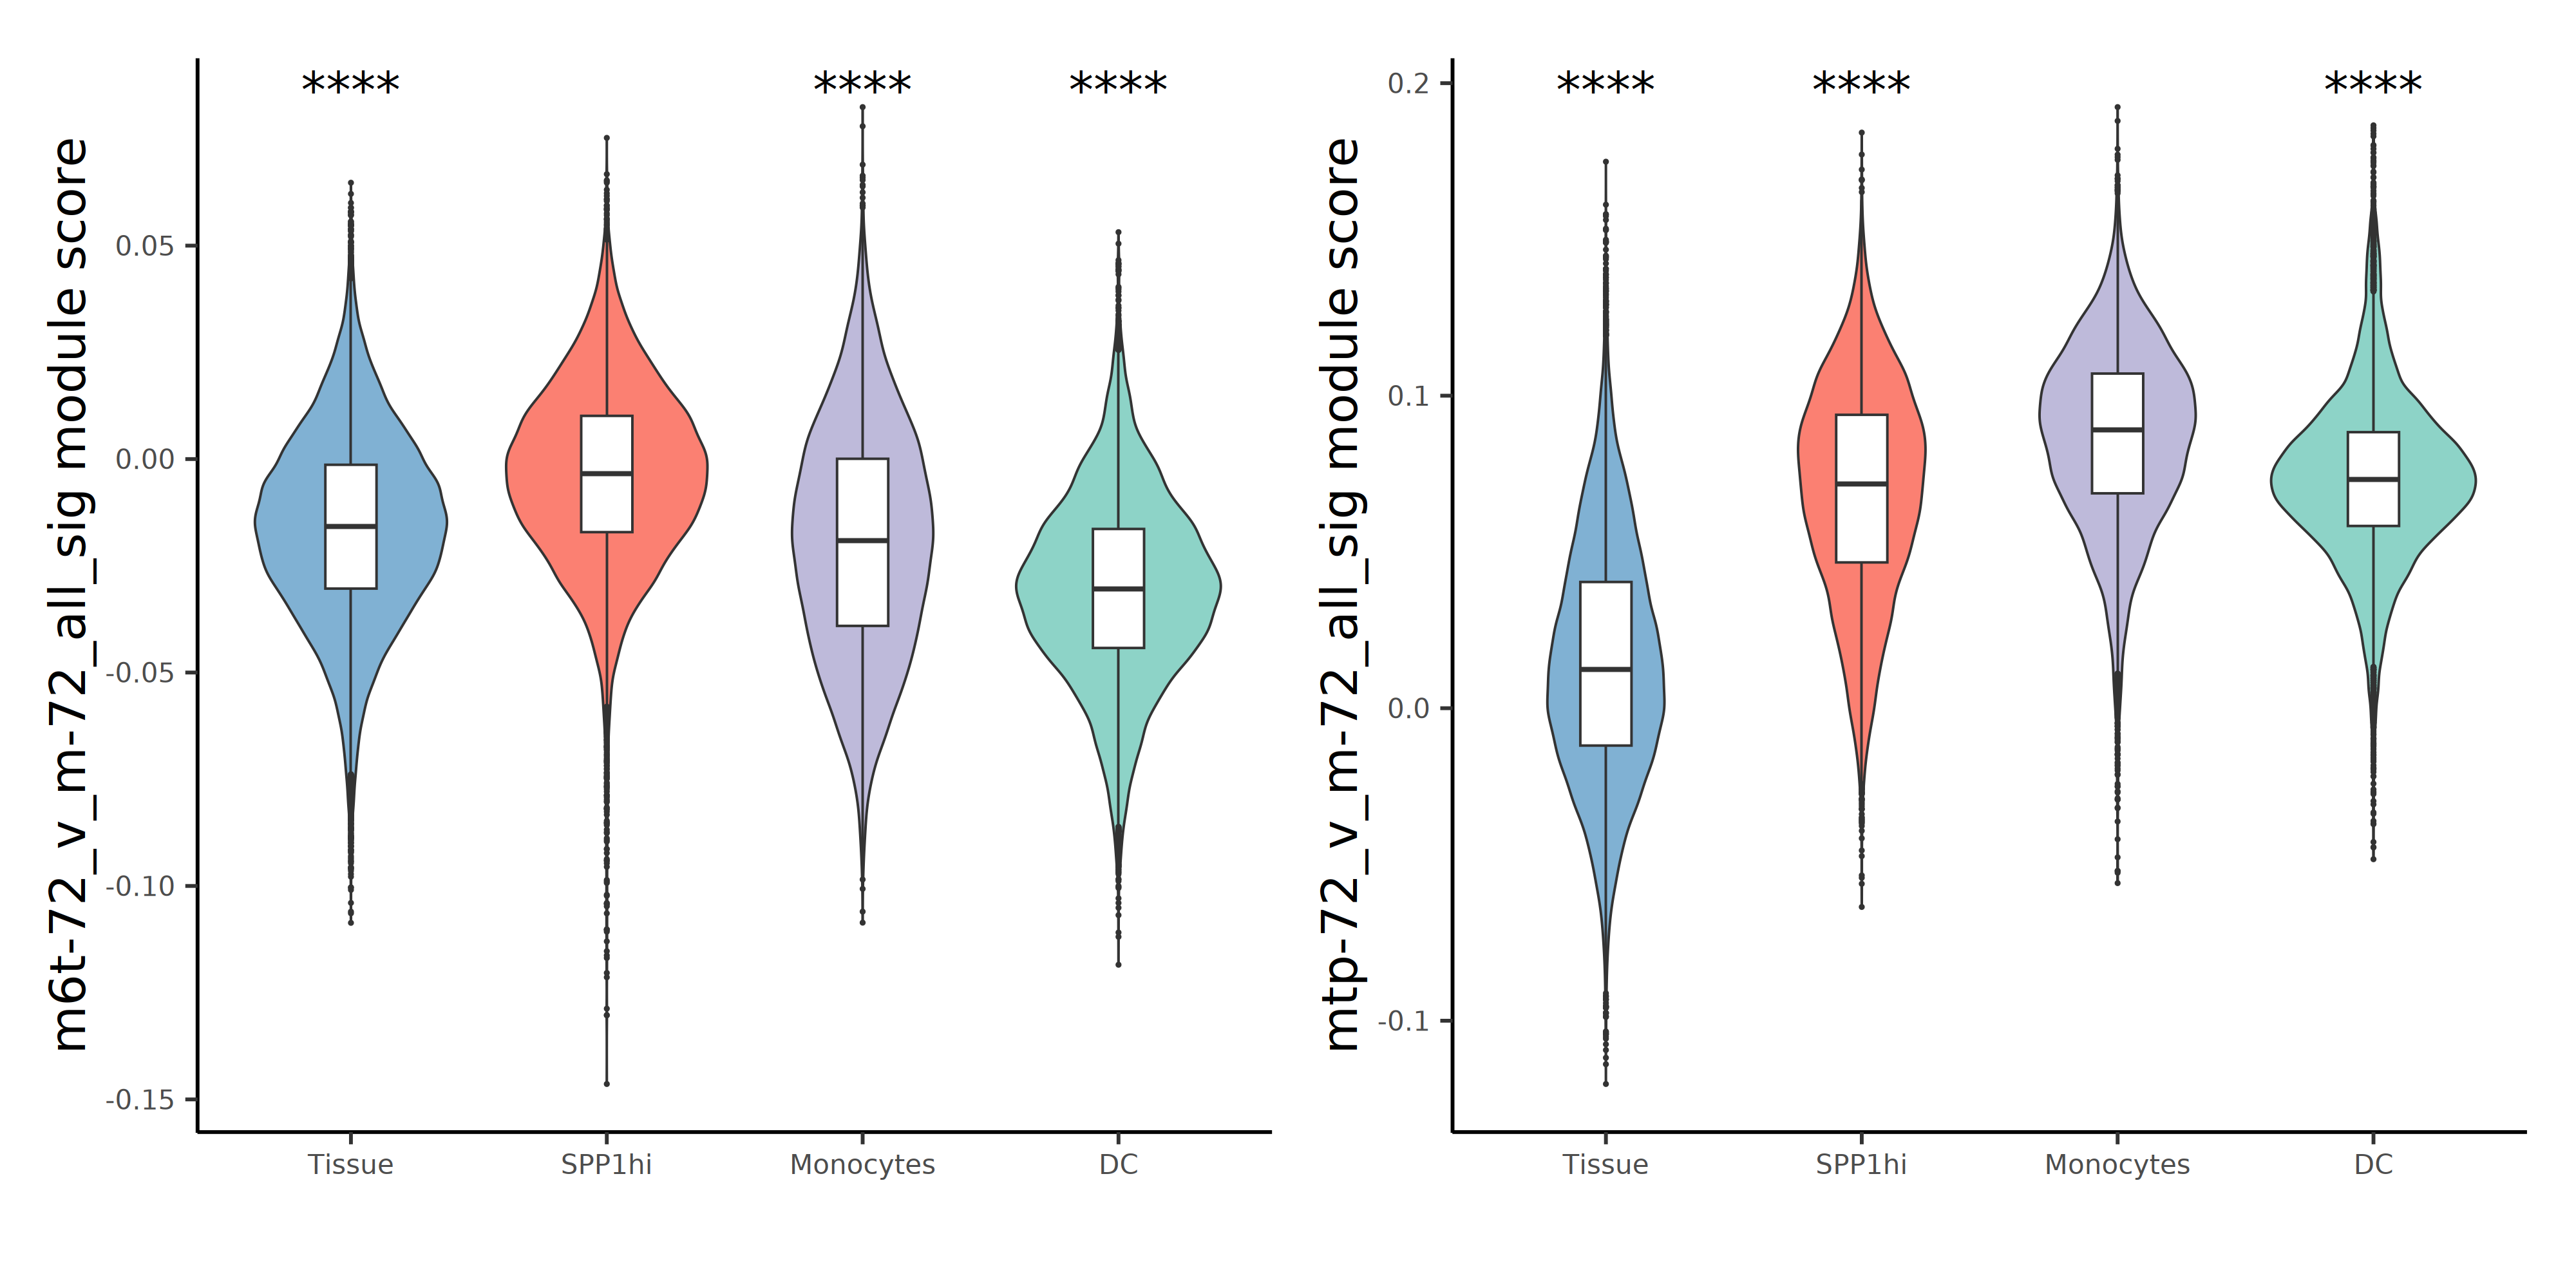

In [42]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 500)
all_vln_plot_comparisons
ggsave(filename="/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure3/3C.png",
       dpi=500,
       height=4,
       width=8,
       limitsize=FALSE)

In [43]:
myeloid_reference <- readRDS("/data1/deyk/harry/RA_Xenium/data/Zhang_Nat_2023_AMP/myeloid_reference.rds")

In [44]:
embeddings_myeloid_only <- myeloid_reference$umap$embedding
embeddings_myeloid_only <- data.frame(embeddings_myeloid_only)
rownames(embeddings_myeloid_only) <- myeloid_reference$meta_data$cell

In [45]:
module_score_umap_myeloid <- cbind(embeddings_myeloid_only[rownames(all_module_scores), ], all_module_scores)

In [46]:
plotUMAPFeature <- function(df,
                            embedding_1,
                            embedding_2,
                            variable,
                            palette=rev(paletteer::paletteer_c("grDevices::Reds", n=50)),
                            stroke=0.03,
                            cap=FALSE,
                            cap_quantile=0.98,
                            size=0.3,
                            order_variable=variable,
                            legend_title=variable,
                            midpoint=NA,
                            title="",
                            order=FALSE){
    mid_rescaler <- function(mid) {
      function(x, to = c(0, 1), from = range(x, na.rm = TRUE)) {
        scales::rescale_mid(x, to, from, mid)
      }
    }
    rescaler <- if (is.na(midpoint)) scales::rescale else mid_rescaler(midpoint)
    if(cap){
        df[[variable]] <- pmin(df[[variable]], quantile(df[[variable]], cap_quantile, na.rm=TRUE))
    }
    if(order){
        df <- df %>% arrange(!!sym(order_variable))
    }
    ggplot(df, aes(!!sym(embedding_1), !!sym(embedding_2), fill=!!sym(variable))) +
    geom_point(size=size, stroke=stroke, shape=21) +
    scale_fill_gradientn(colors=palette, rescale=rescaler)  +
    theme_bw() +
    theme(panel.grid=element_blank(),
          plot.title=element_text(size=8),
          legend.key.size=unit(3, "mm"),
          legend.title=element_text(size=8),
          legend.text=element_text(size=5),
          axis.text=element_blank(),
          axis.ticks=element_blank(),
          aspect.ratio=1) +
    ggtitle(title) +
    labs(fill=legend_title)
}

In [47]:
all_umap_plots <- lapply(colnames(all_module_scores), function(module_name){
    plotUMAPFeature(module_score_umap_myeloid,
                    midpoint=NA,
                    "UMAP1",
                    "UMAP2",
                    module_name,
                    size=0.1,
                    stroke=0.005,
                    cap=FALSE,
                    order=FALSE,
                    palette=rev(paletteer::paletteer_c("ggthemes::Red-Blue Diverging", n=100)))
})

In [48]:
all_umap_plots <- wrap_plots(all_umap_plots, ncol=2)

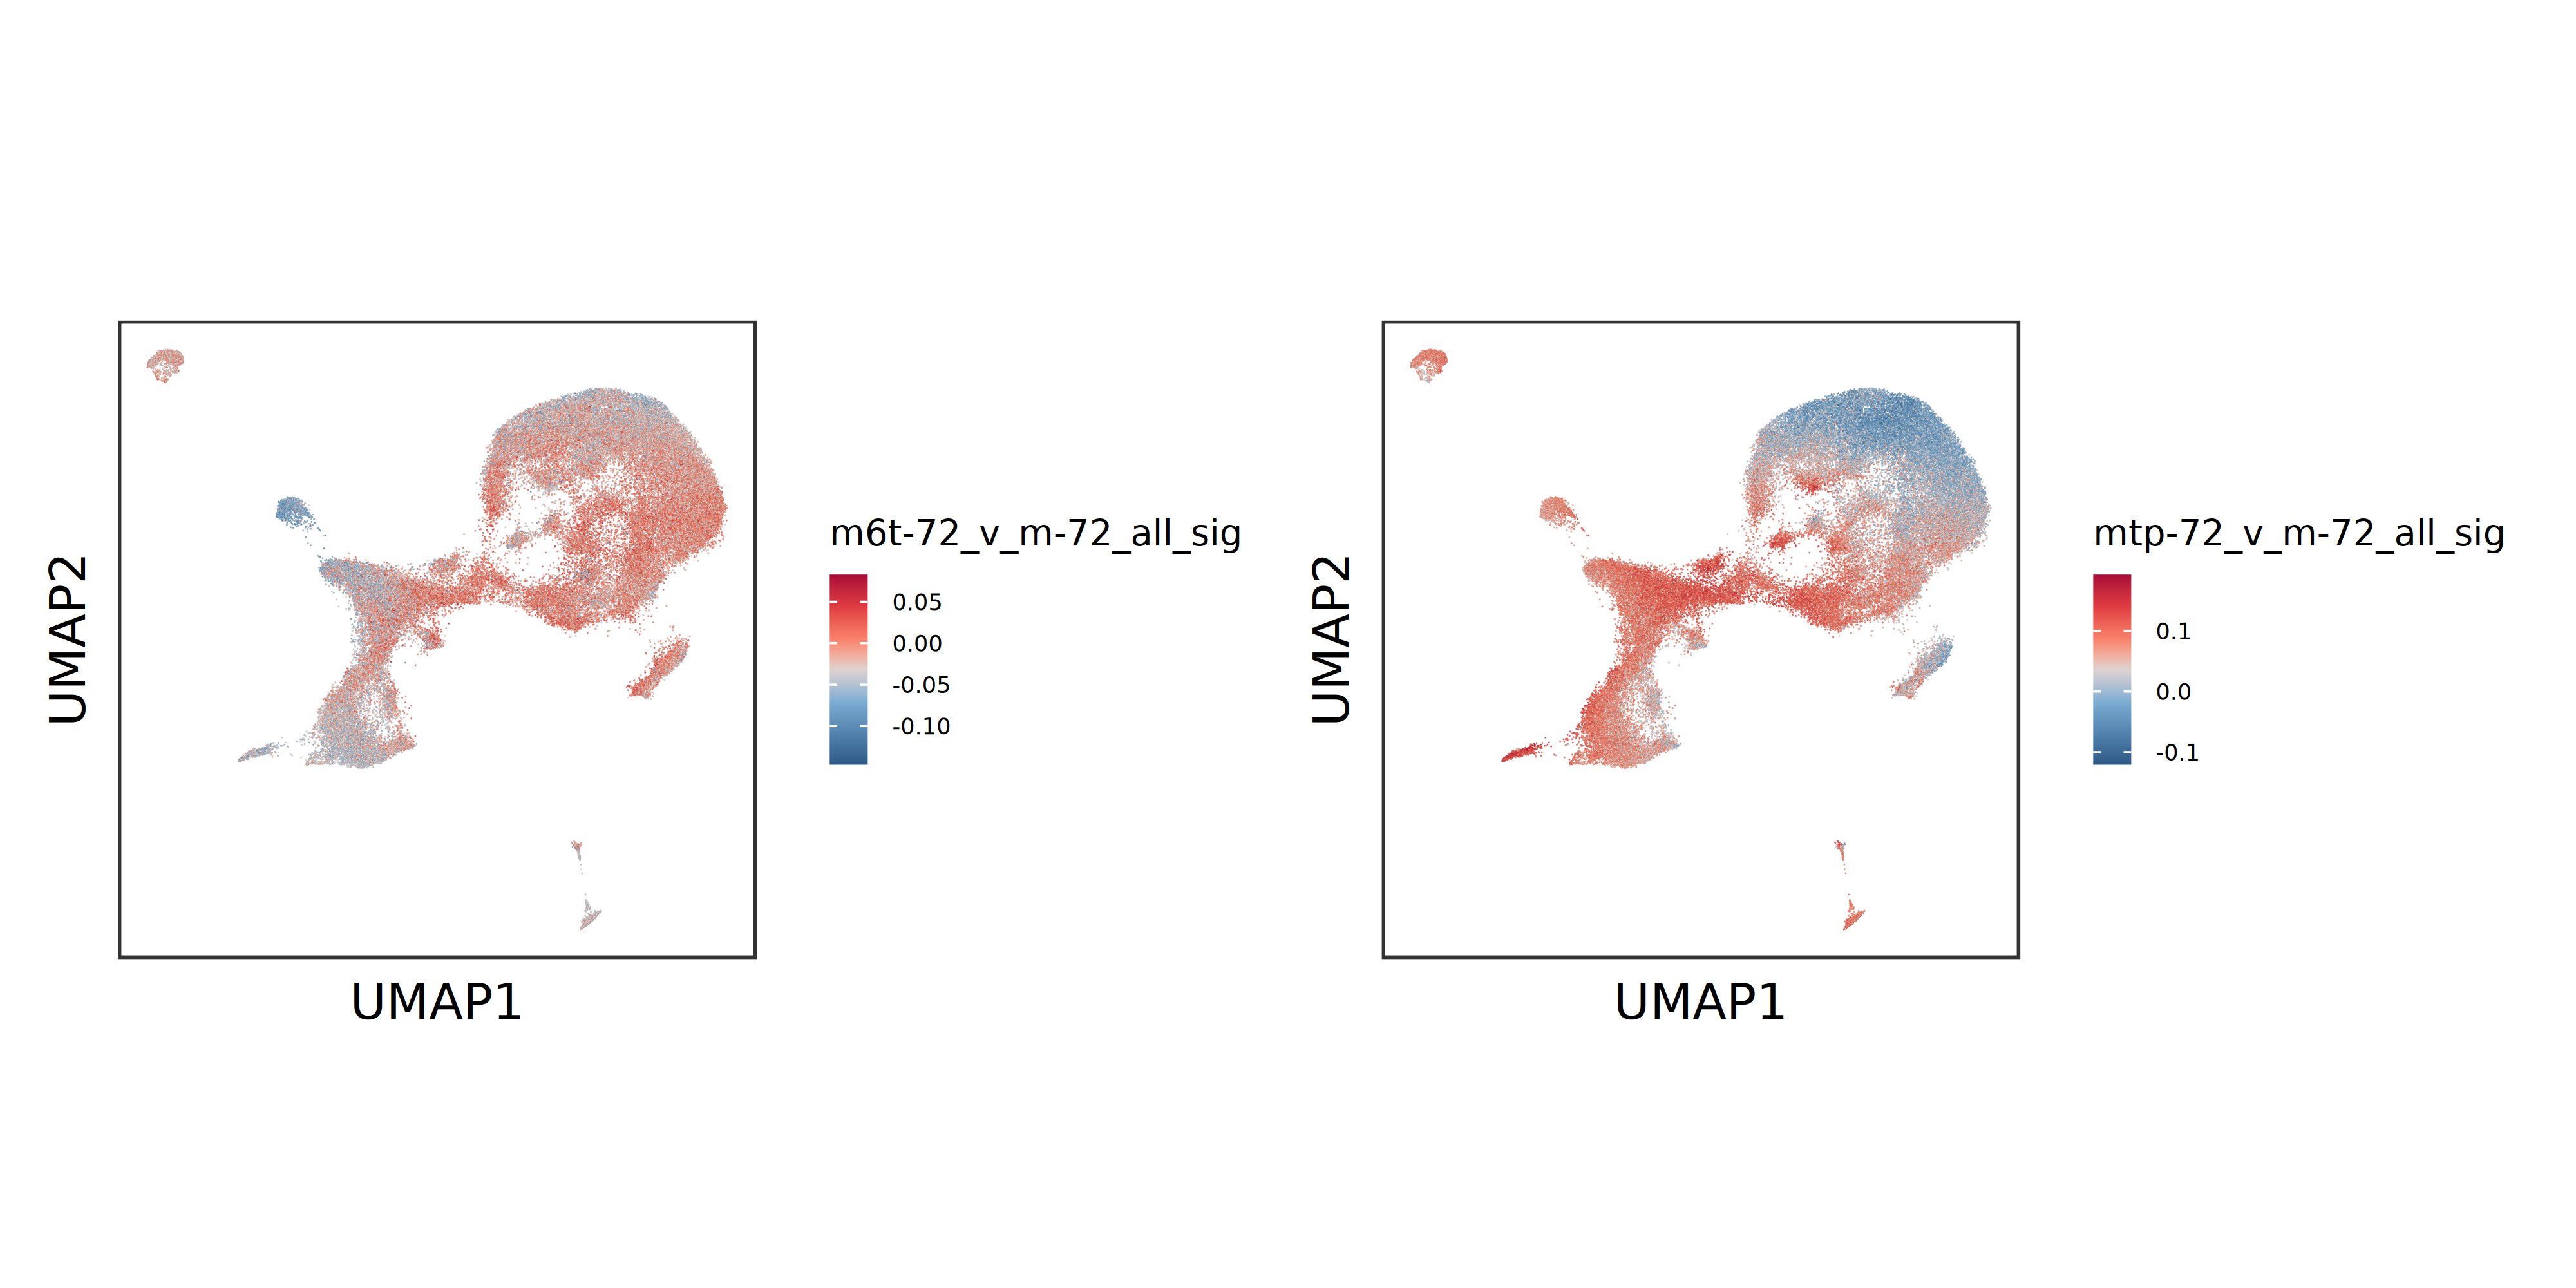

In [50]:
all_umap_plots
ggsave(filename="/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure3/3C_umap.png",
       dpi=500,
       height=4,
       width=8,
       limitsize=FALSE)

# 3E

In [51]:
all_macrophage_subset_query_obj <- list.files("/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/macrophage_seurat", full.names=TRUE)
all_macrophage_subset_query_obj <- lapply(all_macrophage_subset_query_obj, function(file){
    qread(file) -> obj.tmp
    DefaultAssay(obj.tmp) <- "RNA"
    obj.tmp[["SCT"]] <- NULL
    obj.tmp
})

In [52]:
merged_macrophage_query <- merge(all_macrophage_subset_query_obj[[1]],
                                 all_macrophage_subset_query_obj[-1])
merged_macrophage_query <- JoinLayers(merged_macrophage_query)
merged_macrophage_query <- NormalizeData(merged_macrophage_query, normalization.method="LogNormalize", scale.factor=10000)

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Normalizing layer: counts



In [54]:
experiment_design_info <- read_xlsx("/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/IM032 pooling information.xlsx", skip=1)[, 1:5]
colnames(experiment_design_info) <- c("experiment_name", "celltype", "donorID", "soluble_factors", "wFB")
experiment_design_info %>%
    mutate(wFB=ifelse(wFB=="w/ fib", "+Fib", "-Fib"),
           design=paste(soluble_factors, wFB, sep="")) -> experiment_design_info
experiment_design_info %>%
    mutate(experiment_name=paste(experiment_name, "_5prime_gex", sep="")) -> experiment_design_info

New names:
• `Cell type` -> `Cell type...2`
• `Donor/Patient ID` -> `Donor/Patient ID...3`
• `Soluble factors` -> `Soluble factors...4`
• `Co-cultured?` -> `Co-cultured?...5`
• `Cell type` -> `Cell type...6`
• `Donor/Patient ID` -> `Donor/Patient ID...7`
• `Soluble factors` -> `Soluble factors...8`
• `Co-cultured?` -> `Co-cultured?...9`


In [55]:
merged_macrophage_query@meta.data %>%
    select(orig.ident) %>%
    left_join(experiment_design_info %>% select(experiment_name, design), by=c("orig.ident"="experiment_name")) %>%
    select(-orig.ident) -> design_df_add
design_df_add <- data.frame(design_df_add)
rownames(design_df_add) <- colnames(merged_macrophage_query)
merged_macrophage_query <- ScaleData(merged_macrophage_query)
merged_macrophage_query <- AddMetaData(merged_macrophage_query, design_df_add)
merged_macrophage_query$design <- gsub("\\+", "plus", merged_macrophage_query$design)
merged_macrophage_query$design <- gsub("\\-", "minus", merged_macrophage_query$design)

Centering and scaling data matrix



In [56]:
gene_lists <- data.frame(read_xlsx("/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/gene_list_dotplot_07142025.xlsx"))
scrna_seq_defined_spp1_genes <- c("MARCO", "RNASE1", "CXCL3", "NUPR1", "S100A8", 
  "APOE", "HBEGF", "SPP1", "LPL", "FN1", 
  "FABP5", "CLEC5A")

In [57]:
avg_exp <- AverageExpression(object=merged_macrophage_query, group.by="design", slot="scale.data", features=scrna_seq_defined_spp1_genes)
percent_expressing <- Percent_Expressing(seurat_object=merged_macrophage_query, features=scrna_seq_defined_spp1_genes, group_by="design")
percent_expressing %>%
    mutate(gene=rownames(.)) %>%
    pivot_longer(!gene, names_to="design", values_to="pct_exp") -> percent_expressing
percent_expressing$design <- gsub("plus", "+", percent_expressing$design)
percent_expressing$design <- gsub("minus", "-", percent_expressing$design)
scaled_avg_exp <- avg_exp$RNA
data.frame(scaled_avg_exp) %>%
        mutate(gene=rownames(.)) %>%
        pivot_longer(!gene, names_to="design", values_to="z_avg_exp") -> scaled_avg_exp
    scaled_avg_exp$design <- gsub("plus", "+", scaled_avg_exp$design)
    scaled_avg_exp$design <- gsub("minus", "-", scaled_avg_exp$design)
    percent_expressing %>%
        left_join(scaled_avg_exp, by=c("gene", "design")) -> design_dot_plot
    design_dot_plot$design <- gsub("plus", "+", design_dot_plot$design)
    design_dot_plot$design <- gsub("minus", "-", design_dot_plot$design)

In [58]:
color_scale_breaks <- c(quantile(design_dot_plot$z_avg_exp, 0.02), quantile(design_dot_plot$z_avg_exp, 0.98))
    ggplot(design_dot_plot, aes(gene,
                              design,
                              color=z_avg_exp,
                              size=pct_exp)) +
    scale_size_continuous(range=c(0, 4), breaks=seq(25, 75, 25)) +
    scale_color_scico(palette="vik", midpoint=0, breaks=color_scale_breaks, labels=c("Low", "High")) +
    geom_point() +
    theme_bw() +
    theme(axis.text.x=element_text(colour="black", angle=45, hjust=1, size=8),
          axis.text.y=element_text(colour="black", size=8),
          legend.key.height=unit(0.4, 'cm'),
          legend.key.width=unit(0.35, 'cm'),
          panel.grid.major=element_blank(),
          panel.grid.minor=element_blank(),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7)) +
    ylab("") +
    xlab("") +
    labs(color="Scaled\nExpression",
         size="% Expressed") -> design_dot_plot_image
    design_dot_plot %>%
    select(-pct_exp) %>%
    pivot_wider(names_from=design, values_from=z_avg_exp) %>%
    tibble::column_to_rownames("gene") %>%
    as.matrix(.) -> dend_data
    dend_data  %>%
        dist() %>%
        hclust() %>%
        ggtree(branch.length="none") +
        layout_dendrogram() -> gene_dendro

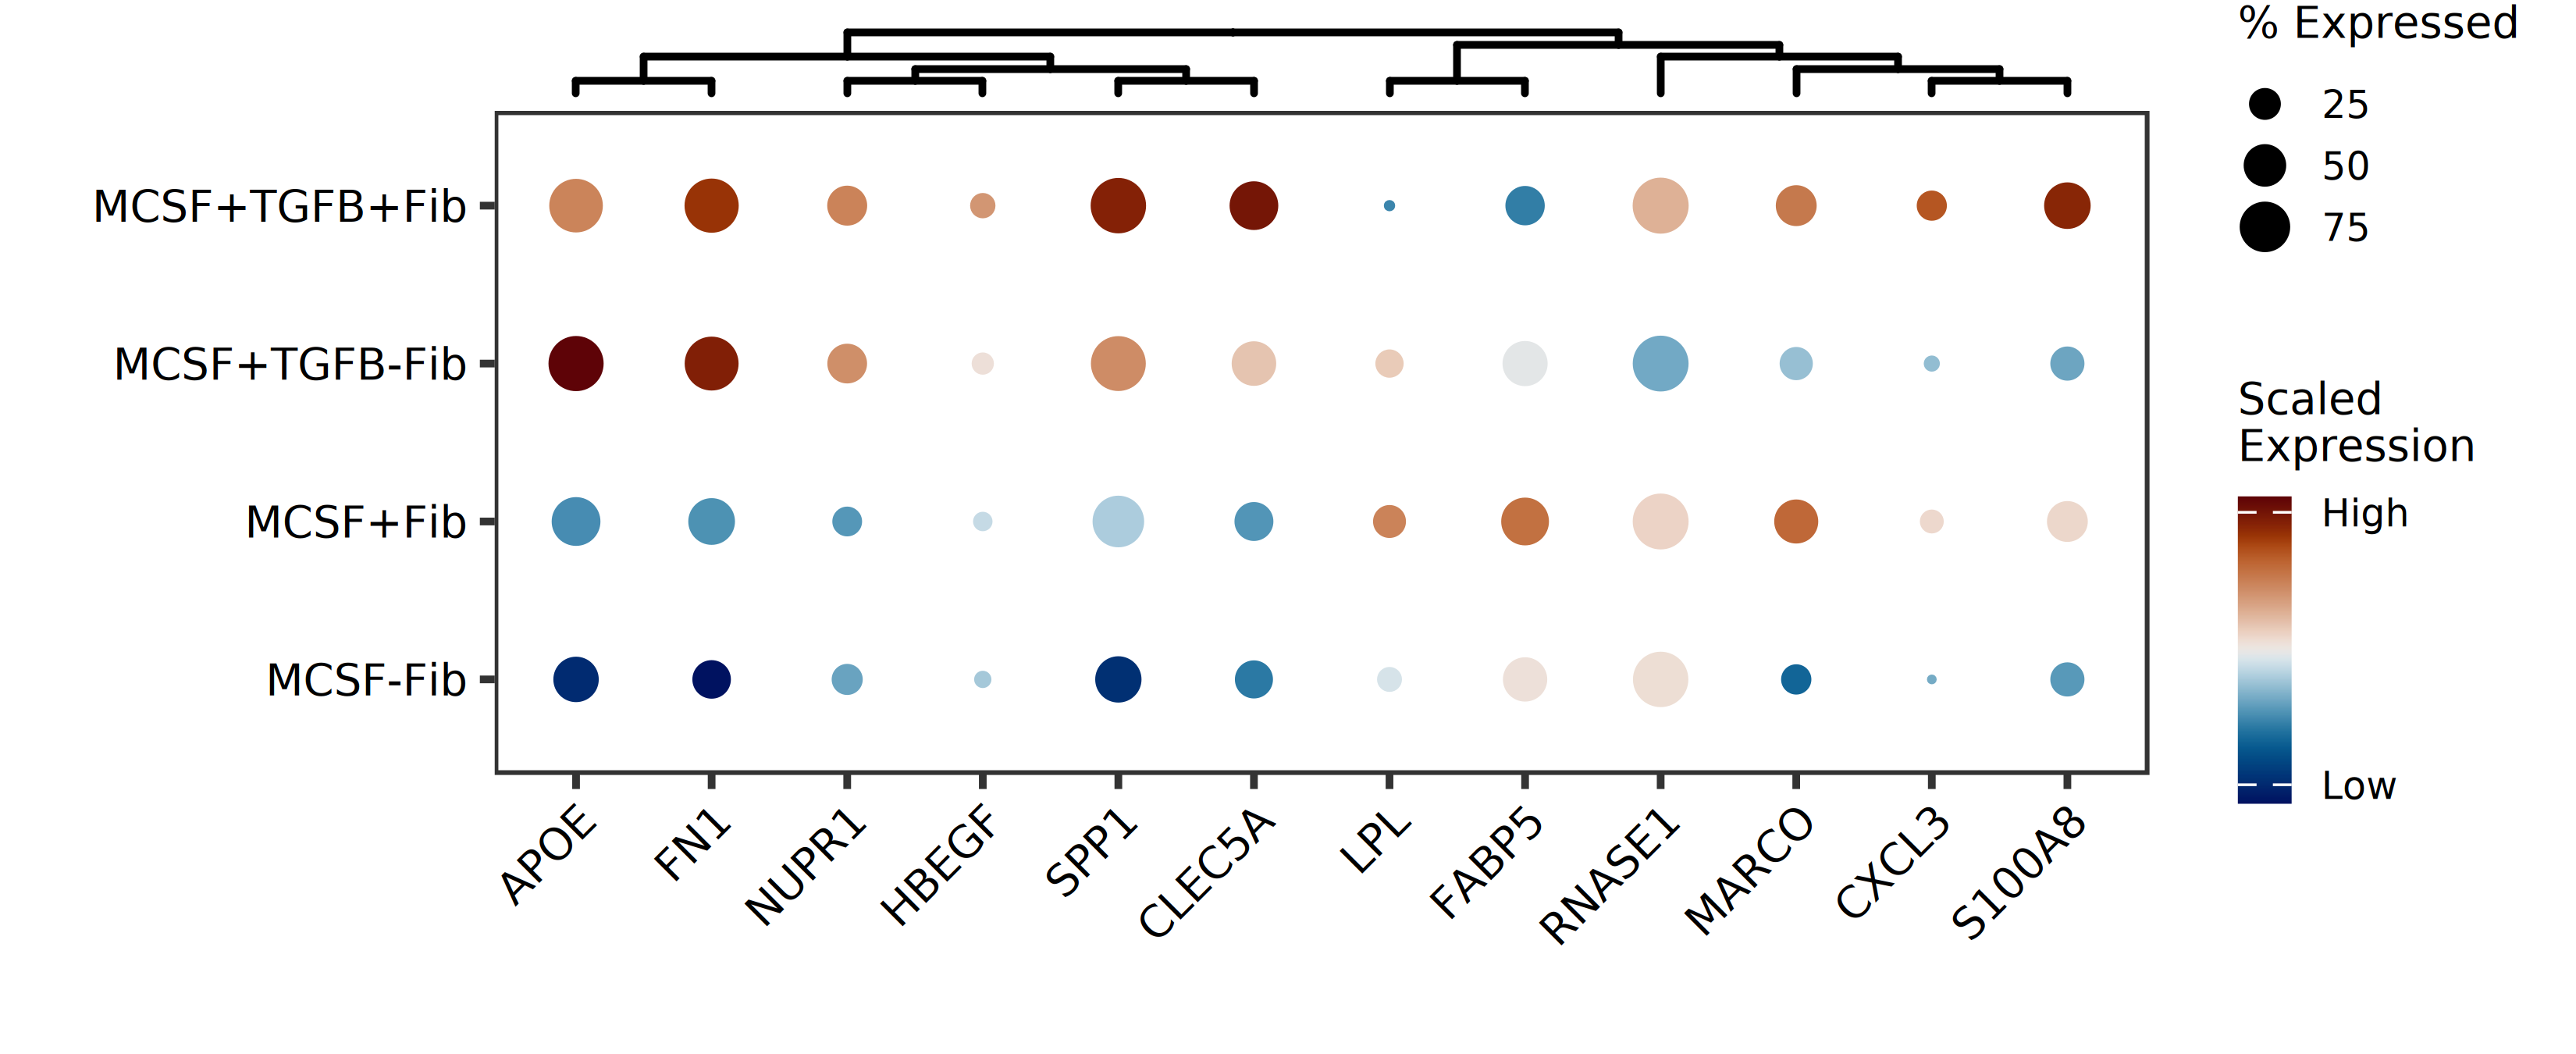

In [60]:
options(repr.plot.width = 6.6, repr.plot.height = 2.7, repr.plot.res = 500)
design_dot_plot_image %>%
    aplot::insert_top(gene_dendro, height=0.1)
ggsave(filename="/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure3/3E_umap.png",
       dpi=500,
       height=2.7,
       width=6.6,
       limitsize=FALSE)

# 3I

In [4]:
all_ra_samples <- list.dirs("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/", recursive=FALSE, full.names=TRUE)
all_sample_ids <- str_extract(all_ra_samples, "RA\\d+[A-Z]*")
height_width_param <- c("6&8", "6.5&7", "6&8", "5&9", "6&8", "7.5&4", "6&10", "6&10", "8&10", "6&8")
names(height_width_param) <- c("RA401", "RA331", "RA442", "RA443", "RA457", "RA480", "RA494", "RA519", "RA362", "RA489")
kmeans_res <- qread("/data1/deyk/harry/RA_Xenium/results/nicheassay/kmeans_res/k_5_res.qs")
kmeans_res <- kmeans_res$cluster
kmeans_niche_df <- data.frame(Niche=kmeans_res) %>%
    mutate(sample=gsub("_.+", "", names(kmeans_res)))
kmeans_niche_df <- split(kmeans_niche_df, kmeans_niche_df$sample)
kmeans_niche_df <- lapply(kmeans_niche_df, function(df){
    rownames(df) <- gsub("RA[0-9]+_", "", rownames(df))
    df %>% 
    mutate(Niche=factor(Niche))
})
all_xenium_samples <- lapply(all_sample_ids, function(sample){
    qread(glue("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/{sample}/final_version_seurat_obj.qs"))
})
all_xenium_samples <- lapply(all_xenium_samples, function(obj){
    # discard assays we don't need, merging will be faster this way
    DefaultAssay(obj) <- "Xenium"
    obj[["SCT"]] <- NULL
    obj[["ControlCodeword"]] <- NULL
    obj[["ControlProbe"]] <- NULL
    coords <- GetTissueCoordinates(obj) %>%
        tibble::column_to_rownames("cell")
    obj@images <- list()
    obj <- AddMetaData(obj, coords)
    return(obj)
})
all_xenium_samples <- setNames(all_xenium_samples, all_sample_ids)
all_xenium_samples <- lapply(names(all_xenium_samples), function(sample){
    AddMetaData(all_xenium_samples[[sample]], kmeans_niche_df[[sample]])
})
all_xenium_merged <- merge(all_xenium_samples[[1]], all_xenium_samples[-1])
all_xenium_merged[["Xenium"]] <- JoinLayers(all_xenium_merged[["Xenium"]])
all_xenium_merged <- NormalizeData(all_xenium_merged, normalization.method="LogNormalize")

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Normalizing layer: counts



In [5]:
proliferation_genes <- c("CCNB2", "CDK1", "MKI67", "PCNA", "TOP2A", "UBE2C")
all_xenium_merged <- AddModuleScore(all_xenium_merged, name="Proliferation", features=list("Proliferation"=proliferation_genes), ctrl=20, nbin=24)

In [61]:
spatialValuePlot <- function(df,
                             variable,
                             x_column="centroid_x",
                             y_column="centroid_y",
                             pt.size=0.2,
                             stroke=0.05,
                             ct.column="",
                             midpoint=NA,
                             plt.ct="",
                             title=variable,
                             palette=paletteer_c("viridis::inferno", n=30),
                             order=TRUE,
                             legend_title=variable,
                             custom_scale=FALSE,
                             scale_externel=NULL){
    mid_rescaler <- function(mid) {
      function(x, to = c(0, 1), from = range(x, na.rm = TRUE)) {
        scales::rescale_mid(x, to, from, mid)
      }
    }
    rescaler <- if (is.na(midpoint)) scales::rescale else mid_rescaler(midpoint)
    sp_aspect_ratio <- diff(range(df[, y_column]))/diff(range(df[, x_column]))
    if(nchar(plt.ct) > 0 & nchar(ct.column) > 0){
        df <- df %>%
        filter(!!sym(ct.column)==plt.ct)
    }
    if(order){
        df <- df %>%
        arrange(!!sym(variable))
    }
    color_bar <- if(custom_scale){scale_externel}else{scale_fill_gradientn(colors=palette, rescale=rescaler)}
    scale_bar_x_start <- min(df[, x_column, drop=TRUE]) + 50
    scale_bar_x_end <- min(df[, x_column, drop=TRUE]) + 50 + 1000
    scale_bar_y_pos <- min(df[, y_column, drop=TRUE] + 50)
    ggplot(df, aes(!!sym(x_column), !!sym(y_column), fill=!!sym(variable))) +
    geom_point(stroke=stroke, size=pt.size, shape=21) +
    theme_bw() +
    theme(aspect.ratio=sp_aspect_ratio,
          legend.key.size=unit(0.2, "cm"),
          legend.title=element_text(size=8, face="bold"),
          legend.text=element_text(size=5),
          panel.grid = element_blank(),
          axis.text=element_blank(),
          axis.ticks=element_blank(),
          plot.title=element_text(size=8, face="bold")) +
    color_bar +
    labs(x="sp1",
         y="sp2",
         fill=legend_title) +
    ggtitle(title) +
    annotate("segment",
             x=scale_bar_x_start,
             xend=scale_bar_x_end,
             y=scale_bar_y_pos,
             yend=scale_bar_y_pos,
             linewidth=0.5) +
    annotate("text",
             x=(scale_bar_x_start+scale_bar_x_end)/2,
             y=scale_bar_y_pos,
             label=paste0(1, " mm"),
             vjust=1.5,
             size=1.5)
}
getSharedScales <- function(values,
                            midpoint){
    min_val <- min(values)
    max_val <- max(values)
    mid_rescaler <- function(mid) {
      function(x, to = c(0, 1), from = range(x, na.rm = TRUE)) {
        scales::rescale_mid(x, to = to, from = from, mid = mid)
      }
    }
    rescaler <- mid_rescaler(midpoint)
    shared_scales <- scale_fill_gradientn(colors=palette,
                                          limits=c(min_val, max_val),
                                          rescaler=rescaler)
    return(shared_scales)
                            }

In [55]:
all_xenium_merged@meta.data %>%
    filter(celltype_broad=="myeloid") -> all_myeloid_plt
all_myeloid_plt[["Proliferation1"]] <- pmin(all_myeloid_plt[["Proliferation1"]], quantile(all_myeloid_plt[["Proliferation1"]], 0.995, na.rm=TRUE))
getSharedScales(all_myeloid_plt$Proliferation1, 0) -> myeloid_prolif_shared_scale

In [ ]:
all_prolif_myeloid_plots <- lapply(all_sample_ids, function(sample_id){
    spatialValuePlot(all_myeloid_plt %>% filter(sample==sample_id),
                     midpoint=0,
                     palette=paletteer_c("pals::coolwarm", n=50),
                     pt.size=0.4,
                     stroke=0,
                     variable="Proliferation1",
                     x_column="y",
                     y_column="x",
                     order=TRUE,
                     legend_title="")
})
names(all_prolif_myeloid_plots) <- all_sample_ids
save_prolif_myeloid_plts <- lapply(all_sample_ids, function(sample_id){
    figure_height_width <- as.numeric(str_split(height_width_param[sample_id], "&")[[1]])
    ggsave(plot=all_prolif_myeloid_plots[[sample_id]],
           filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure3/proliferation/myeloid/{sample_id}.png"),
           height=figure_height_width[1],
           width=figure_height_width[2],
           dpi=500,
           limitsize=FALSE)
})

In [60]:
# all_xenium_merged@meta.data %>%
#     filter(celltype_broad=="fibroblast-cells") -> all_fibro_plt
# all_fibro_plt[["Proliferation1"]] <- pmin(all_fibro_plt[["Proliferation1"]], quantile(all_fibro_plt[["Proliferation1"]], 0.995, na.rm=TRUE))
# getSharedScales(all_fibro_plt$Proliferation1, 0) -> fibro_prolif_shared_scale

In [72]:
# all_prolif_fibro_plots <- lapply(all_sample_ids, function(sample_id){
#     spatialValuePlot(all_fibro_plt %>% filter(sample==sample_id),
#                      custom_scale=TRUE,
#                      scale_externel=fibro_prolif_shared_scale,
#                      pt.size=0.4,
#                      stroke=0,
#                      variable="Proliferation1",
#                      x_column="y",
#                      y_column="x",
#                      order=TRUE,
#                      legend_title="")
# })
# names(all_prolif_fibro_plots) <- all_sample_ids
# save_prolif_fibro_plts <- lapply(all_sample_ids, function(sample_id){
#     figure_height_width <- as.numeric(str_split(height_width_param[sample_id], "&")[[1]])
#     ggsave(plot=all_prolif_fibro_plots[[sample_id]],
#            filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure3/proliferation/fibroblast/{sample_id}.png"),
#            height=figure_height_width[1],
#            width=figure_height_width[2],
#            dpi=500,
#            limitsize=FALSE)
# })